<a href="https://colab.research.google.com/github/sanjaybat66-arch/Assignment-1/blob/main/E_commerce_Conversion_Funnel_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E-commerce Conversion Funnel Analysis

## Objective

The objective of this project is to analyze customer behavior through the e-commerce conversion funnel. The project identifies customer drop-off at each stage, calculates conversion rates, detects bottlenecks, and provides business recommendations to improve conversions.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/sample_data/2019-Nov.csv')
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461.0,2.053014e+18,electronics.smartphone,xiaomi,489.07,520088904.0,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088.0,2.053014e+18,appliances.sewing_machine,janome,293.65,530496790.0,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664.0,2.053014e+18,NaN,creed,28.31,561587266.0,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530.0,2.053014e+18,appliances.kitchen.washer,lg,712.87,518085591.0,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775.0,2.053014e+18,electronics.smartphone,xiaomi,183.27,558856683.0,313628f1-68b8-460d-84f6-cec7a8796ef2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226521 entries, 0 to 226520
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     226521 non-null  object 
 1   event_type     226520 non-null  object 
 2   product_id     226520 non-null  float64
 3   category_id    226520 non-null  float64
 4   category_code  151507 non-null  object 
 5   brand          192508 non-null  object 
 6   price          226520 non-null  float64
 7   user_id        226520 non-null  float64
 8   user_session   226520 non-null  object 
dtypes: float64(4), object(5)
memory usage: 15.6+ MB


In [7]:
df.shape


(226521, 9)

In [9]:
df.isnull().sum()

,0
event_time,0
event_type,1
product_id,1
category_id,1
category_code,75014
brand,34013
price,1
user_id,1
user_session,1


In [11]:
df.describe()

,product_id,category_id,price,user_id
count,2.265200e+05,2.265200e+05,226520.000000,2.265200e+05
mean,1.081459e+07,2.057663e+18,286.293402,5.350289e+08
std,1.200824e+07,1.919533e+16,345.757222,2.024173e+07
min,1.000978e+06,2.053014e+18,0.000000,2.752567e+08
25%,1.005217e+06,2.053014e+18,66.670000,5.158499e+08
50%,5.100722e+06,2.053014e+18,166.230000,5.303377e+08
75%,1.570018e+07,2.053014e+18,358.310000,5.542422e+08
max,6.050001e+07,2.180737e+18,2574.070000,5.663324e+08


In [12]:
df.columns


Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='object')

In [13]:
df.duplicated().sum()

np.int64(85)

In [19]:
df = df.drop_duplicates().copy()

In [21]:
df['event_time'] = pd.to_datetime(df['event_time'], errors='coerce')

In [22]:
df['event_type'].value_counts()

,count
event_type,
view,219423
purchase,3959
cart,3053


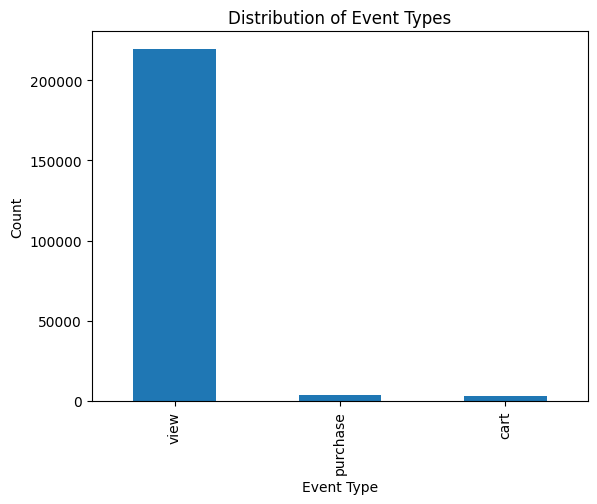

In [24]:
df['event_type'].value_counts().plot(kind='bar')

plt.title("Distribution of Event Types")
plt.xlabel("Event Type")
plt.ylabel("Count")

plt.show()

In [25]:
df['brand'].value_counts().head(10)

,count
brand,
samsung,27646
apple,21492
xiaomi,16786
huawei,5075
lucente,3201
cordiant,2977
oppo,2928
bosch,2709
lg,2688


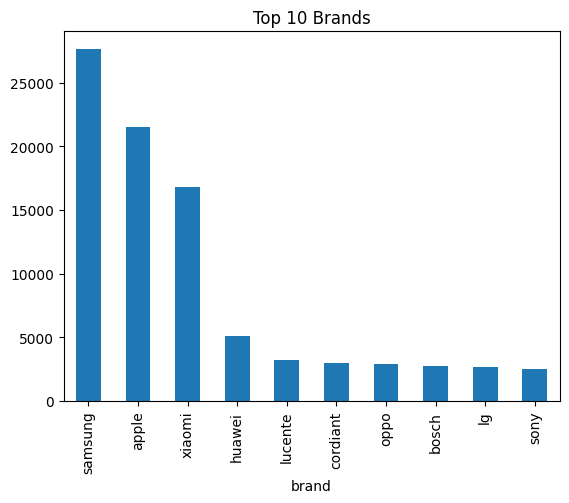

In [26]:
df['brand'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Brands")
plt.show()

In [27]:
df['category_code'].value_counts().head(10)

,count
category_code,
electronics.smartphone,59428
electronics.audio.headphone,6261
electronics.clocks,6228
computers.notebook,6106
electronics.video.tv,5925
apparel.shoes,4440
appliances.kitchen.washer,4309
appliances.environment.vacuum,4306
appliances.kitchen.refrigerators,4174


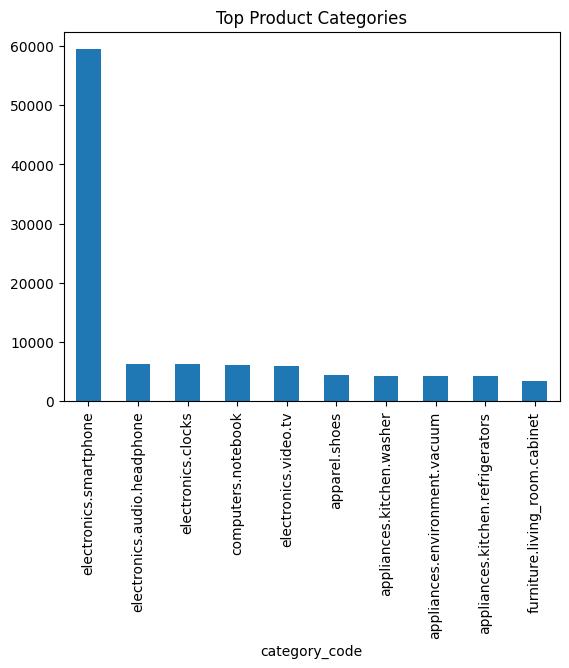

In [28]:
df['category_code'].value_counts().head(10).plot(kind='bar')

plt.title("Top Product Categories")

plt.show()

In [29]:
df[['brand','price']].sort_values(by='price',ascending=False).head(10)

,brand,price
1167,NaN,2574.07
37007,NaN,2574.07
66626,rado,2574.07
125222,NaN,2574.07
36825,NaN,2574.07
1086,NaN,2574.07
128104,NaN,2574.07
127760,NaN,2574.07
108498,NaN,2574.07
7728,NaN,2574.07


In [30]:
df['date']=df['event_time'].dt.date

In [31]:
daily=df.groupby('date').size()

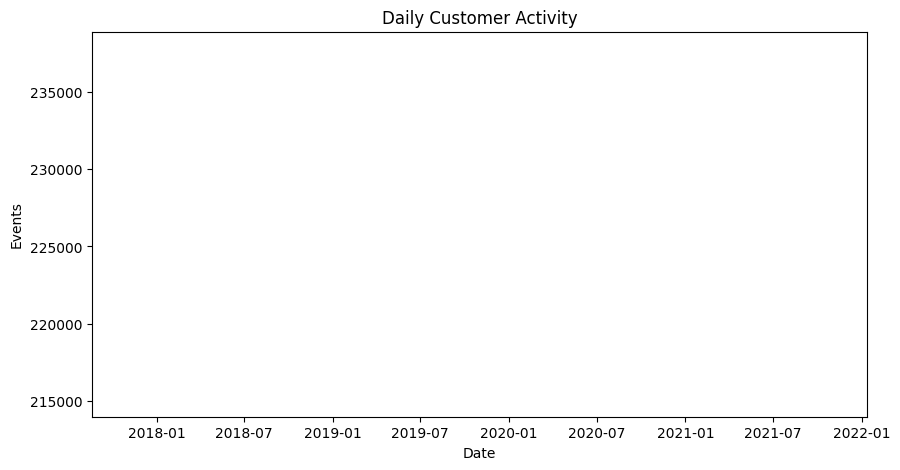

In [32]:
daily.plot(figsize=(10,5))

plt.title("Daily Customer Activity")

plt.xlabel("Date")

plt.ylabel("Events")

plt.show()

In [33]:
df['event_type'].value_counts()

,count
event_type,
view,219423
purchase,3959
cart,3053


In [34]:
funnel = df['event_type'].value_counts()
print(funnel)

event_type
view        219423
purchase      3959
cart          3053
Name: count, dtype: int64


In [35]:
views = funnel['view']
cart = funnel['cart']
purchase = funnel['purchase']

In [36]:
view_to_cart = (cart / views) * 100

cart_to_purchase = (purchase / cart) * 100

overall_conversion = (purchase / views) * 100

In [37]:
print("View to Cart Conversion :", round(view_to_cart,2),"%")

print("Cart to Purchase Conversion :", round(cart_to_purchase,2),"%")

print("Overall Conversion :", round(overall_conversion,2),"%")

View to Cart Conversion : 1.39 %
Cart to Purchase Conversion : 129.68 %
Overall Conversion : 1.8 %


In [38]:
view_drop = views - cart

cart_drop = cart - purchase

In [39]:
print("Users lost after View :", view_drop)

print("Users lost after Cart :", cart_drop)

Users lost after View : 216370
Users lost after Cart : -906


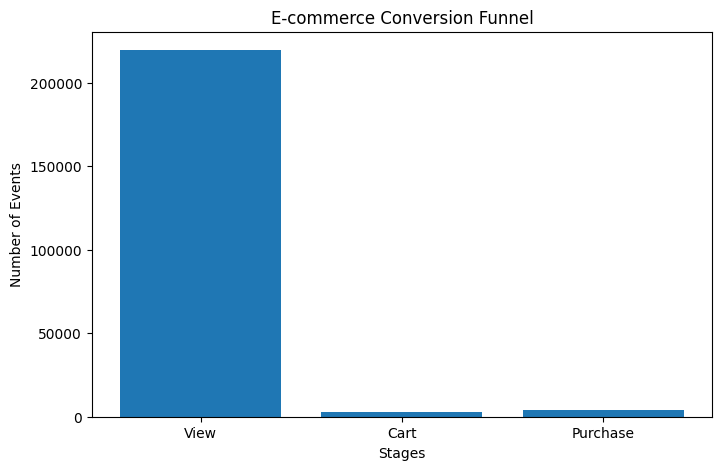

In [40]:
stages = ['View', 'Cart', 'Purchase']

counts = [views, cart, purchase]

plt.figure(figsize=(8,5))

plt.bar(stages, counts)

plt.title("E-commerce Conversion Funnel")

plt.xlabel("Stages")

plt.ylabel("Number of Events")

plt.show()

### **INSIGHTS**
- The majority of customer interactions are product views.
- Only a small percentage of users proceed to the cart stage.
- The purchase stage has the lowest number of events.
- The highest customer drop-off occurs between the View and Cart stages.
- This indicates that many customers browse products but do not show enough purchase intent.

### **FUNNEL BOTTLENECK**

The biggest bottleneck in the conversion funnel is between the View and Cart stages.

Although many customers view products, only a small percentage add them to the cart.

This suggests that customers may not find enough value, trust, or motivation to continue their purchase journey.

### **BUSINESS RECOMMENDATIONS**
1. Improve product images and descriptions.

2. Display customer reviews and ratings.

3. Offer discounts or coupons.

4. Provide free shipping on eligible orders.

5. Simplify the checkout process.

6. Recommend related products to customers.

### **CONCLUSION**
This project analyzed the e-commerce conversion funnel using customer event data.

The funnel stages (View → Cart → Purchase) were examined to identify customer behavior and drop-off points.

Conversion rates between stages were calculated, and the major bottleneck was identified.

Based on the analysis, several business recommendations were suggested to improve customer conversions and increase sales.